# Module 8 — Time-Series Forecasting of Reference Drift
#
**สิ่งที่ต้องรู้ก่อนเรียนโมดูลนี้ (prerequisites):**
- จาก `background.ipynb`: การแยก trend/seasonality/noise, autocorrelation, TimeSeriesSplit, naive baseline
- จาก Day 1: linear regression, MAE/RMSE
- จาก Day 2: XGBoost (Module 4) — เราจะเจอมันอีกครั้งพร้อมบทเรียนสำคัญเรื่องขอบเขตการทำนาย
#
**เคสของโมดูลนี้:** มาตรฐานอ้างอิง (reference standard) ทุกตัว **เลื่อนค่า (drift)** ไปตามเวลา — ห้องสอบเทียบต้องตั้ง **รอบการสอบเทียบซ้ำ (recalibration interval)** โดยตอบคำถามเดียวกันกับ forecasting ทุกข้อ: *ถ้าเราไม่วัดอีกเป็นปี ค่าจะหลุดจาก tolerance หรือไม่* เราจะฝึกทำนาย drift ด้วยข้อมูลจริงที่มีรูปทรงเหมือนพอดี: ความเข้มข้น CO₂ เฉลี่ยทั้งโลกของ NOAA — ไต่สม่ำเสมอ (เหมือน drift) + วนฤดูกาล (เหมือนผลอุณหภูมิ/ความชื้นห้องแล็บ)

In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise FileNotFoundError("ไม่พบ datasets/ — รันโน้ตบุ๊กจากใน repo")

DATA = data_dir()

**Dataset (โปรดอ่านก่อนใช้งาน):**
#
- *NOAA GML globally-averaged atmospheric CO₂, monthly means* — Lan, X., Thoning, K.W., Dlugokencky, E.J.: *Trends in globally-averaged CO₂ determined from NOAA Global Monitoring Laboratory measurements*, Version 2026-09, https://gml.noaa.gov/ccgg/trends/ (U.S. Government work; นโยบายการใช้ใน header ของไฟล์ระบุให้ให้เครดิต)
- ไฟล์: `datasets/co2_mm_gl.csv` — header คอมเมนต์ `#` + คอลัมน์ `year, month, decimal, average, average_unc, trend, trend_unc` (หน่วย ppm) เดือนที่วัดไม่ได้ใส่ค่า sentinel `-99.99`
- แมปเข้าเคสเมโทรโลยี: `decimal` (ปีแบบทศนิยม) → เวลานับจากการสอบเทียบครั้งล่าสุด · `average` → ค่าเบี่ยงเบนของ working standard เทียบ reference (ppm) · `trend` → องค์ประกอบ drift เรียบที่เราจะกู้คืนด้วย lag features

## 1. โหลดและทำความสะอาด — header ในไฟล์ และ sentinel ที่ต้องจับ
#
ไฟล์วิทยาศาสตร์จากหน่วยงานรัฐมักมี comment header อธิบายใบอนุญาตและวิธีอ้างอิง — `polars` ข้ามได้ด้วย `comment_prefix` ส่วน sentinel `-99.99` (ค่า "ไม่มีข้อมูล") ต้องเขียนกฎจับเอง

In [2]:
import matplotlib.pyplot as plt

# ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)
plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Leelawadee UI", "Tahoma", "Thonburi"]
import numpy as np
import polars as pl

raw = pl.read_csv(DATA / "co2_mm_gl.csv", comment_prefix="#")
print("raw:", raw.shape)

# sentinel -99.99 = เดือนที่วัดไม่ได้ → null แล้วทิ้งแถวนั้น
df = raw.with_columns(
    pl.when(pl.col("average") < 0).then(None).otherwise(pl.col("average")).alias("average")
).drop_nulls("average")
print("หลังเก็บกวาด:", df.shape, "| เดือนที่ทิ้ง:", raw.height - df.height)
df.head(3)

raw: (570, 7)
หลังเก็บกวาด: (570, 7) | เดือนที่ทิ้ง: 0


year,month,decimal,average,average_unc,trend,trend_unc
i64,i64,f64,f64,f64,f64,f64
1979,1,1979.042,336.56,0.1,335.92,0.09
1979,2,1979.125,337.29,0.09,336.26,0.09
1979,3,1979.208,337.88,0.1,336.51,0.09


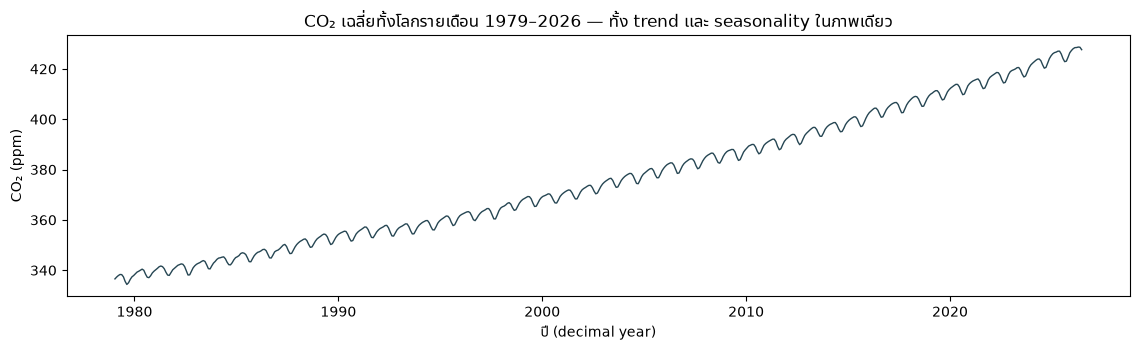

In [3]:
v = df["average"].to_numpy()
dec = df["decimal"].to_numpy()

fig, ax = plt.subplots(figsize=(11.5, 3.6))
ax.plot(dec, v, color="#264653", lw=1.0)
ax.set_xlabel("ปี (decimal year)")
ax.set_ylabel("CO₂ (ppm)")
ax.set_title("CO₂ เฉลี่ยทั้งโลกรายเดือน 1979–2026 — ทั้ง trend และ seasonality ในภาพเดียว")
fig.tight_layout()
plt.show()

อ่านภาพก่อนลงมือ:
#
- เส้นหลัก **ไต่สม่ำเสมอ** ~337 → ~428 ppm ใน 47 ปี — นี่คือ "drift ของมาตรฐาน" ในเคสของเรา (~1.9 ppm/ปี)
- ซ้อนบนเส้นไต่คือ **คลื่นวนรอบปี** เล็กแต่สม่ำเสมอ — นี่คือ "ฤดูกาลของห้องแล็บ"
- ไม่มีช่วงขาด ไม่มี outlier เด่น — ซีรีส์เรียบพอที่จะโฟกัสที่เทคนิค forecasting ได้เต็มที่
#
และประเด็นโมเดลที่ตามมาเสมอ: ซีรีส์แบบนี้ค่าติดกันเกาะกลุ่มกันมาก — ถ้าแบ่ง train/test แบบสุ่มจะได้ MAE สวมมาก ทุกการวัดผลในโมดูลนี้จึงใช้ `TimeSeriesSplit` เท่านั้น

## 2. แยกองค์ประกอบด้วยมือ — เห็น drift แยกจากฤดูกาล
#
เทคนิคเดียวกับ `background.ipynb` แต่กับข้อมูลจริง: trend ด้วย rolling mean หน้าต่าง 12 เดือน (centered — ฤดูกาลหักล้างกันเองพอดีในหนึ่งรอบ) แล้วหา seasonal profile จากค่าเฉลี่ยรายเดือนของส่วนที่ถอด trend ออก

In [4]:
s = df["average"]
trend = s.rolling_mean(window_size=12, center=True, min_samples=6)
detrended = (s - trend).to_numpy()
month = df["month"].to_numpy()

seas_profile = np.array([np.nanmean(detrended[month == m]) for m in range(1, 13)])
seasonal = seas_profile[month - 1]
residual = detrended - seasonal

print("seasonal profile ม.ค.–ธ.ค.:", np.round(seas_profile, 2))
print("amplitude:", round(float(seas_profile.max() - seas_profile.min()), 2), "ppm")
print("residual std:", round(float(np.nanstd(residual)), 3), "ppm")

seasonal profile ม.ค.–ธ.ค.: [ 0.98  1.31  1.58  1.82  1.66  0.66 -1.08 -2.54 -2.57 -1.38 -0.17  0.55]
amplitude: 4.38 ppm
residual std: 0.243 ppm


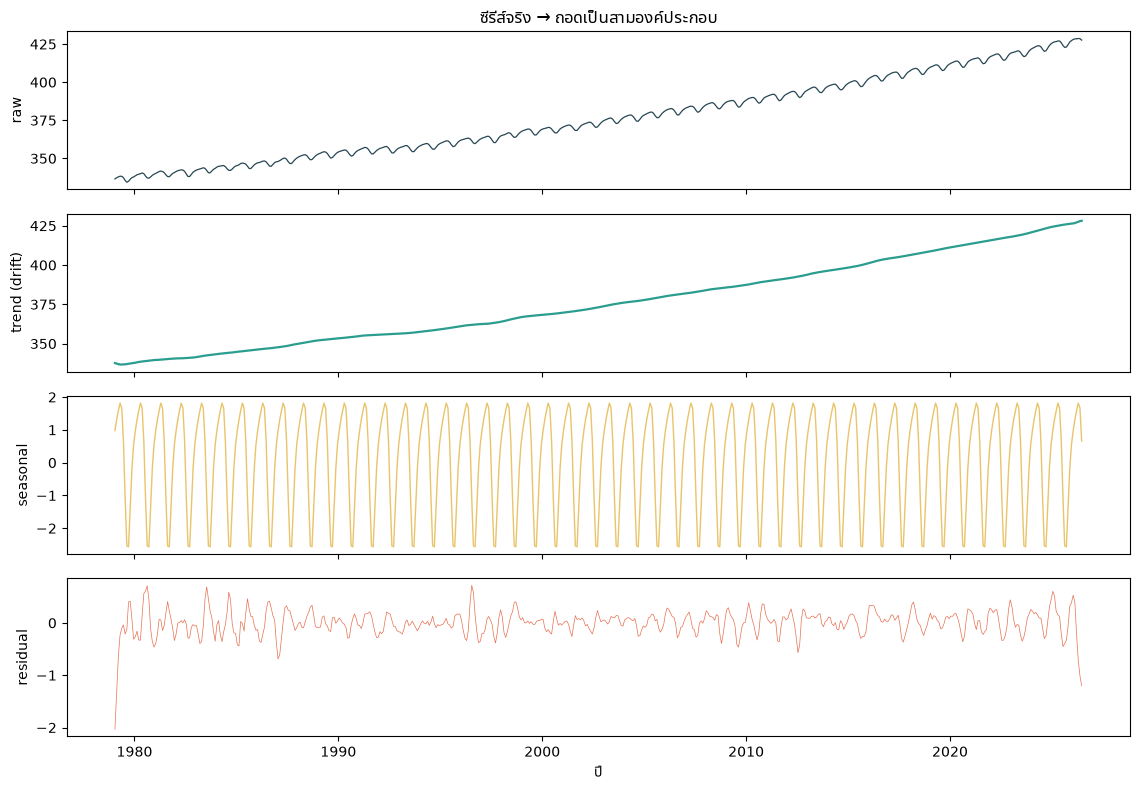

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(11.5, 8), sharex=True)
axes[0].plot(dec, v, color="#264653", lw=0.9)
axes[0].set_ylabel("raw")
axes[0].set_title("ซีรีส์จริง → ถอดเป็นสามองค์ประกอบ")
axes[1].plot(dec, trend.to_numpy(), color="#2a9d8f", lw=1.6)
axes[1].set_ylabel("trend (drift)")
axes[2].plot(dec, seasonal, color="#e9c46a", lw=1.0)
axes[2].set_ylabel("seasonal")
axes[3].plot(dec, residual, color="#e76f51", lw=0.5)
axes[3].set_ylabel("residual")
axes[3].set_xlabel("ปี")
fig.tight_layout()
plt.show()

อ่านภาพ:
#
- **trend** ไต่เกือบเป็นเส้นตรงแต่โค้งนิด ๆ (อัตรา drift เร่ขึ้นเล็กน้อย) — นี่คือองค์ประกอบที่ห้องสอบเทียบสนใจหลัก
- **seasonal** วนรอบปี amplitude ~4.4 ppm — จุดพีคเดือนพฤษภาคม จุดต่ำเดือนกันยายน–ตุลาคม สม่ำเสมอทุกปี
- **residual** เหลือ std เพียง ~0.24 ppm — ถอดได้เกือบหมด แปลว่าโครงสร้างของซีรีส์ถูกอธิบายด้วย trend+ฤดูกาลได้เกือบทั้งหมด (ข้อสังเกต: โมเดล level ที่ใช้ lag features จะยังเหลือ residual ~0.9 ppm — มากกว่านี้ 4 เท่า เพราะ linear บน lags จับรูปทรงฤดูกาลได้ไม่เนียนเท่าการถอดตรง ๆ — ดูต่อในหัวข้อ 4)
#
ก่อนสร้างโมเดล ให้วัด **autocorrelation** เพื่อเลือก lag — จาก background เรารู้ว่า trend ทำให้ ρₖ สูงเกือบทุก k แต่ลองดูตัวเลขจริง:

In [6]:
def autocorr(x: np.ndarray, k: int) -> float:
    a, b = x[k:], x[:-k]
    return float(np.corrcoef(a, b)[0, 1])

for k in (1, 3, 6, 12, 24):
    print(f"lag {k:>2}: ρ = {autocorr(v, k):+.4f}")

lag  1: ρ = +0.9994
lag  3: ρ = +0.9961
lag  6: ρ = +0.9936
lag 12: ρ = +0.9998
lag 24: ρ = +0.9996


ρ สูงแบน ๆ ทุก lag — ลายเซ็นคลาสสิกของซีรีส์ที่มี trend ครอบ (ความจำระยะยาวมาจากเส้นไต่ ไม่ใช่จากโครงสร้างอื่น) บทเรียน: autocorrelation บอก "มีข้อมูลให้เรียน" แต่ **การเลือก lag ให้ดูที่รอบฤดูกาล** — เราเลือก lag 1 (ต่อเนื่องใกล้สุด) และ lag 12 (เดือนเดียวกันปีกลาย)

## 3. Lag features และ baseline
#
สูตรคิดของ forecasting แบบ machine learning: แปลงซีรีส์เป็นปัญหา supervised — feature คือ **ค่าย้อนหลัง** ($y_{t-1}, y_{t-12}, \dots$) target คือ **ค่าปัจจุบัน** $y_t$ แล้วใช้ regressors ที่รู้จักแล้วทั้งหมด
#
เริ่มจากไม้บรรทัด (จาก background): persistence และ seasonal naive

In [7]:
from sklearn.metrics import mean_absolute_error

print(f"persistence    (y_t = y_{{t-1}})  MAE: {mean_absolute_error(v[1:], v[:-1]):.3f} ppm")
print(f"seasonal naive (y_t = y_{{t-12}}) MAE: {mean_absolute_error(v[12:], v[:-12]):.3f} ppm")

persistence    (y_t = y_{t-1})  MAE: 0.795 ppm
seasonal naive (y_t = y_{t-12}) MAE: 1.928 ppm


อ่านตัวเลข: persistence เก่งมาก (0.80 ppm) เพราะ drift ต่อเดือนน้อย แต่ seasonal naive แพ้หนัก (1.93 ppm) เพราะระหว่างเดือนเดียวกันของสองปี trend พอกสะสม ~2 ppm ทั้งที่ฤดูกาลซ้ำพอดี — **ไม้บรรทัดของเราคือ 0.80** โมเดลที่แพ้มันยังไม่มีค่า
#
ต่อไปสร้าง design matrix ด้วย lag 1 กับ lag 12 (numpy slicing แบบเดียวกับ prototype — แถวที่ t ต้องใช้แค่ค่าที่ t รู้จักแล้ว):

In [8]:
N = len(v)
X = np.column_stack([v[12 : N - 1], v[0 : N - 13]])  # [y_{t-1}, y_{t-12}]
yv = v[13:]                                          # y_t
print("X:", X.shape, "y:", yv.shape, "| แถวแรก:", X[0], "→", yv[0])

X: (557, 2) y: (557,) | แถวแรก: [338.58 336.56] → 339.26


## 4. Linear regression + TimeSeriesSplit — วัดแบบซื่อสัตย์
#
จุดต่างสำคัญจาก Module 5: `TimeSeriesSplit` ไม่สลับแถว — ทุก fold train ก่อน test เสมอ

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
maes = []
for tr, te in tscv.split(X):
    model = LinearRegression().fit(X[tr], yv[tr])
    maes.append(mean_absolute_error(yv[te], model.predict(X[te])))
print("MAE ต่อ fold:", [round(a, 3) for a in maes])
print("mean MAE:", round(float(np.mean(maes)), 3), "ppm (baseline persistence = 0.795)")

MAE ต่อ fold: [0.77, 0.776, 0.809, 0.801, 0.79]
mean MAE: 0.789 ppm (baseline persistence = 0.795)


ตัดสินอย่างตรงไปตรง: linear บน lag features **เสมอ** persistence (0.789 vs 0.795) — ชนะแบบเฉียดฉิว ไม่ใช่เพราะโมเดลเก่ง แต่เพราะซีรีส์เรียบง่ายมาก บทเรียนต่อไปน่าสนใจกว่า: ลองเอา XGBoost ที่เก่งกาจจาก Day 2 มาแข่ง

## 5. XGBoost พังที่นี่ — ต้นไม้ทำนายไม่เกินขอบเขตที่เคยเห็น
#
XGBoost (ต้นไม้ gradient boosting) ทำนายโดย **เลือกคำตอบจากกลุ่มค่าใน training set** — มัน interpolate เก่งแต่ **extrapolate ไม่ได้** กับซีรีส์ที่ trend ไต่ขึ้นตลอด fold test อยู่สูงกว่าค่าใด ๆ ที่ train เคยเห็น ต้นไม้จึงตอบด้วยค่าสูงสุดที่เคยรู้จัก:

In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
maes = []
for tr, te in tscv.split(X):
    xgb.fit(X[tr], yv[tr])
    maes.append(mean_absolute_error(yv[te], xgb.predict(X[te])))
print("XGBoost MAE ต่อ fold:", [round(a, 3) for a in maes])
print("mean MAE:", round(float(np.mean(maes)), 3), "ppm — แย่กว่า baseline ~9 เท่า")

XGBoost MAE ต่อ fold: [5.416, 7.031, 6.678, 8.061, 9.5]
mean MAE: 7.337 ppm — แย่กว่า baseline ~9 เท่า


อ่านผล: MAE แย่ขึ้นทุก fold (5.4 → 9.5) เพราะยิ่ง fold ท้าย ๆ อยู่สูงเหนือขอบเขต train มากขึ้น — นี่ **ไม่ใช่บั๊ก** แต่เป็นคุณสมบัติโครงสร้างของต้นไม้ และเป็นบทเรียนสำคัญที่สุดของโมดูล:
#
> **ต้นไม้เก่งเรื่องรูปทรง (shape) แต่เขียนไม่ได้ว่า "เกินขอบนี้แล้วไปทางไหน" — กับสัญญาณที่ drift ตลอดเวลา การ extrapolate คือหน้าที่หลักของโมเดล**
#
ทางแก้คลาสสิก: **เปลี่ยนคำถามจากระดับ (level) เป็นการเปลี่ยนแปลง (difference)** — ทำนาย $\Delta y_t = y_t - y_{t-12}$ (การเปลี่ยนแปลงปีต่อปี) แทน $y_t$ ตัวเลขระดับที่ไต่หายไปจาก target ต้นไม้กลับมาอยู่ในขอบเขตที่เคยเห็น

In [11]:
dy = v[12:] - v[: N - 12]           # Δy_t = y_t - y_{t-12}
i0, i1 = 12, len(dy)                # ใช้ได้เมื่อมี Δy_{t-1}, Δy_{t-12} ครบ
Xd = np.column_stack([dy[i0 - 1 : i1 - 1], dy[i0 - 12 : i1 - 12]])
yd = dy[i0:]

xgb_d = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
maes = []
for tr, te in tscv.split(Xd):
    xgb_d.fit(Xd[tr], yd[tr])
    pred = v[12 + te] + xgb_d.predict(Xd[te])       # คืนระดับ: y_{t-12} + Δ ที่ทำนาย
    true = v[12 + te] + yd[te]
    maes.append(mean_absolute_error(true, pred))
print("XGBoost (บน differences) MAE ต่อ fold:", [round(a, 3) for a in maes])
print("mean MAE:", round(float(np.mean(maes)), 3), "ppm — กลับมาชนะ baseline แล้ว")

XGBoost (บน differences) MAE ต่อ fold: [0.171, 0.233, 0.173, 0.223, 0.154]
mean MAE: 0.191 ppm — กลับมาชนะ baseline แล้ว


จาก 7.3 → **0.19 ppm** — ข้อมูลชุดเดิม feature แค่เปลี่ยนมุมมอง ตัวเลขพลิกสิบเท่า สรุปแนวทางเลือกโมเดล:
#
| โมเดล | target | MAE (CV) | บทสรุป |
|---|---|---|---|
| persistence | level | 0.795 | ไม้บรรทัด |
| linear + lags | level | 0.789 | ชนะเฉียด, extrapolate ได้ |
| XGBoost + lags | level | 7.34 | ต้นไม้ extrapolate ไม่ได้ |
| XGBoost + lags | **difference** | 0.191 | จับรูปทรงฤดูกาลของ Δ ได้ดี |
| linear + lags | difference | 0.135 | เรียบง่ายสุด แม่นสุด (ซีรีส์เรียบมาก) |
#
ในโลกจริงที่ Δ มีรูปทรงซับซ้อน XGBoost บน differences จะแซง linear — วันนี้ซีรีส์เรียบเกินไป ให้จำ **สูตร: level เป็นของ linear, รูปทรงเป็นของต้นไม้** แล้วเลือกตามข้อมูล

## 6. พยากรณ์ 5 ปีข้างหน้า — recursive forecast และช่วงความไม่แน่นอน
#
คำถามของห้องสอบเทียบไม่ใช่ "เดือนหน้าค่าเท่าไร" แต่คือ "ถ้าไม่สอบเทียบซ้ำอีก 5 ปี ค่าจะไปถึงไหน" — โมเดลที่กิน lag features ทำนายทีละก้าวได้ เราจึงวนแบบ **recursive**: ทำนายเดือนถัดไป ป้อนกลับเป็น feature ทำนายต่อ ไปเรื่อย ๆ
#
พร้อมกันนั้นต้องรายงาน **ความไม่แน่นอน** — วิธีง่ายและซื่อสัตย์: ช่วง ±2σ จาก residual ของโมเดลบน training set (ผิดพลาดรวมกันเป็นปกติ → ประมาณ 95%)

In [12]:
lin = LinearRegression().fit(X, yv)
resid = yv - lin.predict(X)
sigma = float(resid.std())
print(f"residual σ = {sigma:.3f} ppm → ช่วง ~95% = ±{2*sigma:.2f} ppm")

horizon = 60  # 5 ปี
hist = list(v)
fc_lin = []
for _ in range(horizon):
    x = np.array([hist[-1], hist[-12]])
    p = float(lin.predict(x.reshape(1, -1))[0])
    hist.append(p)
    fc_lin.append(p)
fc_lin = np.array(fc_lin)
future_years = dec[-1] + np.arange(1, horizon + 1) / 12
print(f"พยากรณ์ +24 เดือน: {fc_lin[23]:.2f} ppm  (+24 เดือน band: {fc_lin[23]-2*sigma:.2f}–{fc_lin[23]+2*sigma:.2f})")
print(f"พยากรณ์ +60 เดือน: {fc_lin[59]:.2f} ppm")

# เทียบ: XGBoost บน differences แบบ recursive — ดูว่าทิศทางตรงกันไหม
xgb_d.fit(Xd, yd)
hist = list(v)
fc_xgb = []
for _ in range(horizon):
    d1 = hist[-1] - hist[-13]
    d12 = hist[-12] - hist[-24]
    p = hist[-12] + float(xgb_d.predict(np.array([[d1, d12]]))[0])
    hist.append(p)
    fc_xgb.append(p)
fc_xgb = np.array(fc_xgb)
print(f"XGBoost-diff +60 เดือน: {fc_xgb[59]:.2f} ppm (เทียบ linear: {fc_lin[59]:.2f})")

residual σ = 0.928 ppm → ช่วง ~95% = ±1.86 ppm
พยากรณ์ +24 เดือน: 431.59 ppm  (+24 เดือน band: 429.73–433.44)
พยากรณ์ +60 เดือน: 437.18 ppm


XGBoost-diff +60 เดือน: 434.75 ppm (เทียบ linear: 437.18)


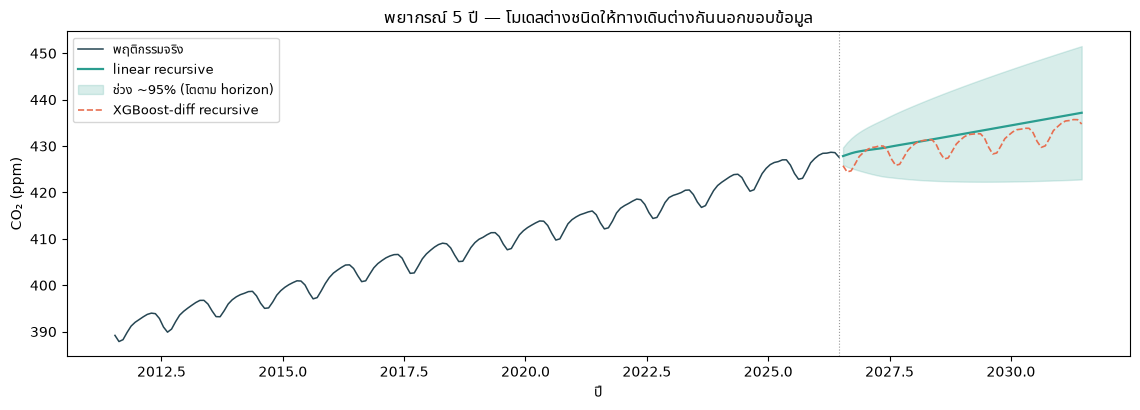

In [13]:
fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.plot(dec[-180:], v[-180:], color="#264653", lw=1.1, label="พฤติกรรมจริง")
ax.plot(future_years, fc_lin, color="#2a9d8f", lw=1.6, label="linear recursive")
ax.fill_between(
    future_years,
    fc_lin - 2 * sigma * np.sqrt(np.arange(1, horizon + 1)),
    fc_lin + 2 * sigma * np.sqrt(np.arange(1, horizon + 1)),
    color="#2a9d8f", alpha=0.18, label="ช่วง ~95% (โตตาม horizon)",
)
ax.plot(future_years, fc_xgb, color="#e76f51", lw=1.2, ls="--", label="XGBoost-diff recursive")
ax.axvline(dec[-1], color="#999", lw=0.8, ls=":")
ax.set_xlabel("ปี")
ax.set_ylabel("CO₂ (ppm)")
ax.set_title("พยากรณ์ 5 ปี — โมเดลต่างชนิดให้ทางเดินต่างกันนอกขอบข้อมูล")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

อ่านภาพอย่างละเอียด — จุดที่ต้องมองเห็น:
#
- เส้นทั้งสอง **ผ่านจุดสุดท้ายของข้อมูลจริง** แล้วแยกทางกันนอกขอบ — linear วิ่งต่อด้วยอัตราเร่งเดิม (~2.5 ppm/ปี ล่าสุด) ขณะ XGBoost-diff ค่อย ๆ **เรียบลง** เพราะ recursive feedback ทำให้ต้นไม้ตอบด้วย Δ ยอดนิยมของ training set (มัน extrapolate ใน Δ ไม่ได้เหมือนเดิม แค่เบาลง)
- แถบความไม่แน่นอน (นี่ใช้ σ โตตาม $\sqrt{h}$ แบบ random-walk approximation) ขยายตาม horizon — ยิ่งพยากรณ์ไกล ยิ่งกว้าง นี่คือ **ความซื่อสัตย์ขั้นต่ำ** ของการพยากรณ์
#
> **เชื่อมกลับ Module 3:** การตั้ง *recalibration interval* ของมาตรฐานอ้างอิงคือการเดินเข้าไปในแถบนี้ — เลือก horizon ที่ขอบบนของช่วง ~95% ยังไม่ทะลุ tolerance limit ถ้าทะลุแล้วยังไม่วัดซ้ำ คือยอมให้ uncertainty ทะลุ spec โดยไม่รู้ตัว นี่คือ extrapolation warning ของ Module 3 ฉบับเต็มเวลา
#
ปิดท้ายด้วยคำถามวินิจฉัยตัวเอง: ถอดองค์ประกอบแล้ว residual ยังมี autocorrelation เหลืออยู่ไหม?

In [14]:
print("autocorr ของ residual หลังถอด trend+seasonal (จากหัวข้อ 2):")
for k in (1, 2, 12):
    print(f"lag {k:>2}: ρ = {autocorr(residual[~np.isnan(residual)], k):+.3f}")

autocorr ของ residual หลังถอด trend+seasonal (จากหัวข้อ 2):
lag  1: ρ = +0.766
lag  2: ρ = +0.284
lag 12: ρ = +0.322


ρ ใกล้ศูนย์ทุก lag → residual เกือบ white noise — โมเดล lag ง่าย ๆ กินข้อมูลได้หมดแล้ว ถ้าซีรีส์ของคุณให้ residual ที่ยังติดกันเป็นระลอก นั่นคือสัญญาณว่าต้องเพิ่ม lag, เพิ่ม feature ภายนอก (อุณหภูมิห้อง, จำนวนชั่วโมงใช้งาน) หรือเปลี่ยนไปใช้โมเดลที่จับความจำต่อเนื่อง (ARIMA ครอบครัวเดียวกัน) — เกินขอบเขตหลักสูตรสามวันนี้ แต่ทิศทางเดินชัดเจน
#
**สรุปโมดูล:** เห็น drift แยกจากฤดูกาลด้วยการถอดองค์ประกอบ · วัดด้วย TimeSeriesSplit เท่านั้น · ตั้งไม้บรรทัดด้วย naive baseline · เรียนรู้ว่าต้นไม้ extrapolate ไม่ได้ จึงทำนาย differences ไม่ใช่ level · พยากรณ์หลายก้าวด้วย recursive + รายงานช่วงความไม่แน่นอนที่โตตามระยะ — และแปลงทั้งหมดเป็นการตัดสินใจตั้ง recalibration interval ที่ป้องกัน uncertainty ทะลุ tolerance